# 最適化結果の比較（中立化後）: comp_ew / AI 中立化版 / 複合

`05_neutralized` で作った中立化 AI スコアの最適化結果（`bax/output/{ens_lgbm_dnn_neu_sz, comp_ew_{w}_ai_neu_{..}}`）を、
`03_bax_results` と同じ枠組みで評価する。比較対象として `comp_ew`、生スコア `ens_lgbm_dnn`、生スコアとの複合 70:30 / 60:40 も並べる。
最適化条件はすべて同一（`bc.txt` で確認済み: 期間 201212〜202607、推定 TE ≤ 5%、個別 0〜10% / 対 BM ±3%、業種 ±3%、
リスクインデックス ±2sd、回転率 ≤ 15%/月、線形コスト 0.5%、ホライズン 12 か月、USD ニューメレール）。

中立化版の単独は 2 本: `ens_lgbm_dnn_neu`（サイズ + vola60 + セクター。複合に使った方）と `ens_lgbm_dnn_neu_sz`（サイズ + セクターのみ）。

## 中立化のモチベーション

生の AI スコア `ens_lgbm_dnn` は、制約なしの分位分析では高い IC / Q5 超過を示す一方、`03_bax_results` の制約付き最適化では
comp_ew に大きく劣った（グロス超過 3.4% vs 6.6%、IR 0.48 vs 0.92）。`04_style_tilt` でその原因を調べたところ、

- スコアが core ファクターのスタイルに系統的に傾いていた。特に **サイズ（+0.31）と低ボラティリティ（vola60 に −0.51）** のロードが大きく、
  クロスセクション回帰の R² は comp_ew より高かった（= スコアの分散の多くがスタイルで説明される）。
- その結果 **BM 加重平均スコアが +0.8** と正に大きく、「高スコア銘柄 = 大型・低ボラ = BM の中核銘柄」になっていた。
  最適化ではリスクインデックス ±2sd、個別 ±3% の制約があるため、BM に近い銘柄を買い増しても超過リターンに変換できない
  （スコアは BM 加重で既に「取れている」状態で、アクティブウェイトに乗るアルファが小さい）。
- 推定 TE が 4.1% と上限 5% に届かず、リスク予算を使い切れていなかったのも同じ理由。

そこで `05_neutralized` で、Blom 正規化したスコアを **対数サイズ・vola60・セクターダミー** に月次クロスセクション回帰し、
残差を再 Blom したものを `ens_lgbm_dnn_neu` とした（サイズ + セクターのみの `ens_lgbm_dnn_neu_sz` も比較用に作成）。
制約なし評価では中立化で ICIR 0.54 → 0.81、CW 超過 5.4% → 9.7% と改善し、comp_ew との複合 70:30 は制約なしの全指標で comp_ew を上回った。
本ノートブックは、この中立化版が **制約付き最適化でも** comp_ew / 生スコア複合を上回るかを確認するもの。

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, india_tax_schedule, performance_summary, portfolio_returns, quantile_analysis
from alphaeval.bax import BaxOutput, evaluate_bax, factor_attribution, risk_decomposition

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

BAX_ROOT = "../../bax/output"
INPUT_ROOT = "../../input/msci_india_imi"
W = [90, 80, 70, 60, 50]
NEU = [f"comp_ew_{w}_ai_neu_{100 - w}" for w in W]
RAW = ["comp_ew_70_ai_30", "comp_ew_60_ai_40"]
NAMES = ["comp_ew"] + NEU + ["ens_lgbm_dnn_neu", "ens_lgbm_dnn_neu_sz"] + RAW + ["ens_lgbm_dnn"]
HIGHLIGHT = ["comp_ew", "comp_ew_70_ai_neu_30", "comp_ew_50_ai_neu_50", "ens_lgbm_dnn_neu"]
SCORE_PATH = {"comp_ew": "composite/comp_ew", "ens_lgbm_dnn": "my_ai/ens_lgbm_dnn", "ens_lgbm_dnn_neu": "my_ai_neu/ens_lgbm_dnn_neu", "ens_lgbm_dnn_neu_sz": "my_ai_neu/ens_lgbm_dnn_neu_sz", **{n: f"composite/{n}" for n in NEU + RAW}}
BENCHMARK = "msci_india"
RISK_MODEL = "GEMLT"
FPI_TYPE = "trust"
BURN_IN = 12
SECTOR_NAMES = {10: "エネルギー", 15: "素材", 20: "資本財", 25: "一般消費財", 30: "生活必需品", 35: "ヘルスケア", 40: "金融", 45: "情報技術", 50: "通信", 55: "公益", 60: "不動産"}

store = InputStore(INPUT_ROOT)

## 1. 一括評価（税は INR 建てリターンで FIFO ロット台帳）

In [2]:
outs = {n: BaxOutput(f"{BAX_ROOT}/{n}") for n in NAMES}
first = next(iter(outs.values()))
rtn_inr = store.returns(RISK_MODEL, "rtn")
gics = store.alpha("attributes/gics")
schedule = india_tax_schedule(FPI_TYPE)
results = {}
for n, out in outs.items():
    sector = (gics // 1_000_000).reindex(index=out.rebalance_dates).apply(lambda c: c.map(SECTOR_NAMES))
    results[n] = evaluate_bax(out, mapping=sector, tax_schedule=schedule, tax_returns=rtn_inr, burn_in=BURN_IN)
    print(f"{n:24s} done")

comp_ew                  done


comp_ew_90_ai_neu_10     done


comp_ew_80_ai_neu_20     done


comp_ew_70_ai_neu_30     done


comp_ew_60_ai_neu_40     done


...

ens_lgbm_dnn_neu         done


ens_lgbm_dnn_neu_sz      done


comp_ew_70_ai_30         done


comp_ew_60_ai_40         done


ens_lgbm_dnn             done


## 2. 基本指標

In [3]:
rows = {}
for n, r in results.items():
    s = r.summary
    tt = r.tax_table
    net = performance_summary(tt["fund_after_tax"], tt["bm"])
    pos_s, pos_l = tt["gain_short"].clip(lower=0).sum(), tt["gain_long"].clip(lower=0).sum()
    rows[n] = {
        "超過 グロス": s["active_return_gross"], "超過 コスト後": s["active_return"], "超過 税後": net["active_return"],
        "TE 実現": s["tracking_error"], "TE 推定": s["omega_mean"], "実現/推定": s["te_ratio_realized_to_omega"],
        "IR コスト後": s["information_ratio"], "IR 税後": net["information_ratio"],
        "回転率": s["turnover_annual"], "コストドラッグ": s["cost_drag"], "税ドラッグ": s["active_return"] - net["active_return"], "短期比率": pos_s / (pos_s + pos_l) if pos_s + pos_l > 0 else np.nan,
        "勝率": s["hit_rate"], "最大DD 超過": s["max_drawdown_excess"], "銘柄数": s["n_hold_mean"], "アクティブシェア": s["active_share_mean"],
    }
tbl = pd.DataFrame(rows).T
display(tbl.round(3))

,超過 グロス,超過 コスト後,超過 税後,TE 実現,TE 推定,実現/推定,IR コスト後,IR 税後,回転率,コストドラッグ,税ドラッグ,短期比率,勝率,最大DD 超過,銘柄数,アクティブシェア
comp_ew,0.066,0.056,0.042,0.061,0.049,1.238,0.915,0.676,1.128,0.010,0.014,0.457,0.663,-0.108,90.055,0.663
comp_ew_90_ai_neu_10,0.067,0.057,0.043,0.061,0.049,1.229,0.940,0.697,1.139,0.010,0.014,0.473,0.656,-0.101,91.847,0.667
comp_ew_80_ai_neu_20,0.069,0.059,0.044,0.061,0.049,1.230,0.973,0.719,1.162,0.010,0.015,0.482,0.656,-0.099,93.374,0.669
comp_ew_70_ai_neu_30,0.071,0.060,0.044,0.061,0.049,1.236,0.989,0.721,1.203,0.011,0.016,0.500,0.638,-0.102,94.798,0.671
comp_ew_60_ai_neu_40,0.073,0.061,0.044,0.061,0.049,1.239,1.006,0.721,1.266,0.011,0.017,0.525,0.638,-0.107,96.442,0.672
comp_ew_50_ai_neu_50,0.075,0.063,0.044,0.061,0.049,1.235,1.030,0.717,1.326,0.012,0.019,0.549,0.620,-0.109,97.417,0.674
ens_lgbm_dnn_neu,0.069,0.055,0.034,0.062,0.049,1.268,0.880,0.566,1.513,0.014,0.021,0.599,0.589,-0.148,98.025,0.678
ens_lgbm_dnn_neu_sz,0.057,0.043,0.026,0.061,0.048,1.289,0.698,0.413,1.355,0.014,0.017,0.527,0.571,-0.161,93.012,0.693
comp_ew_70_ai_30,0.066,0.055,0.039,0.058,0.049,1.190,0.956,0.658,1.164,0.010,0.017,0.492,0.669,-0.089,84.963,0.658
comp_ew_60_ai_40,0.064,0.054,0.036,0.057,0.048,1.178,0.941,0.619,1.211,0.011,0.018,0.504,0.650,-0.094,82.736,0.653


## 3. 累積図とアルファ横断の棒グラフ

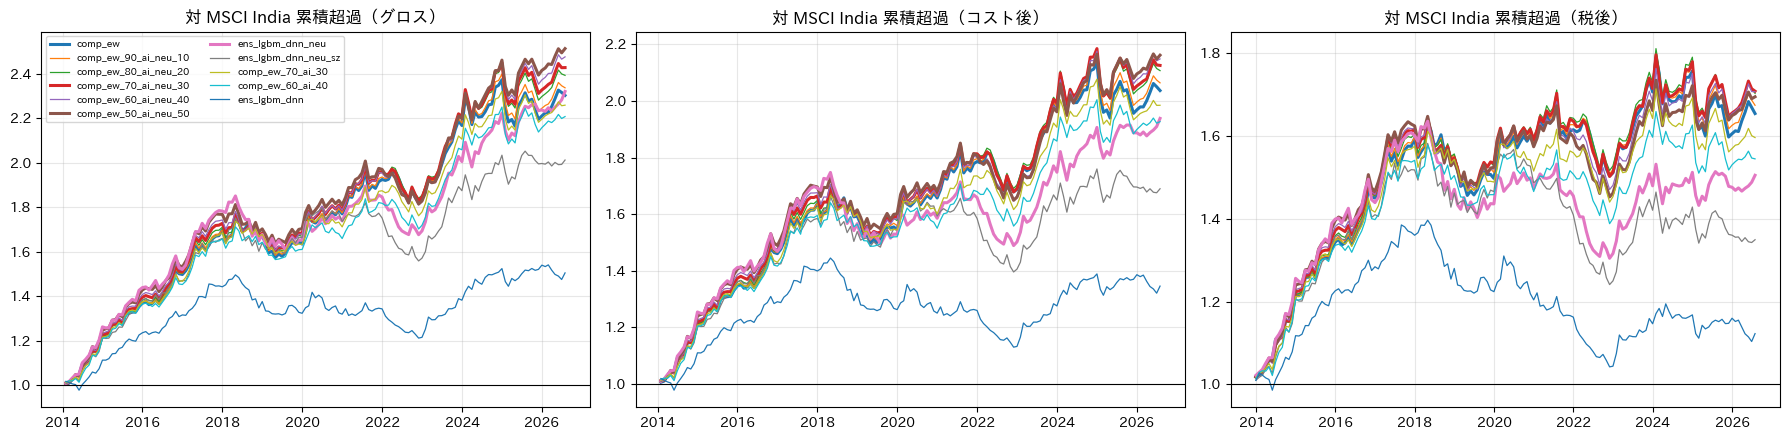

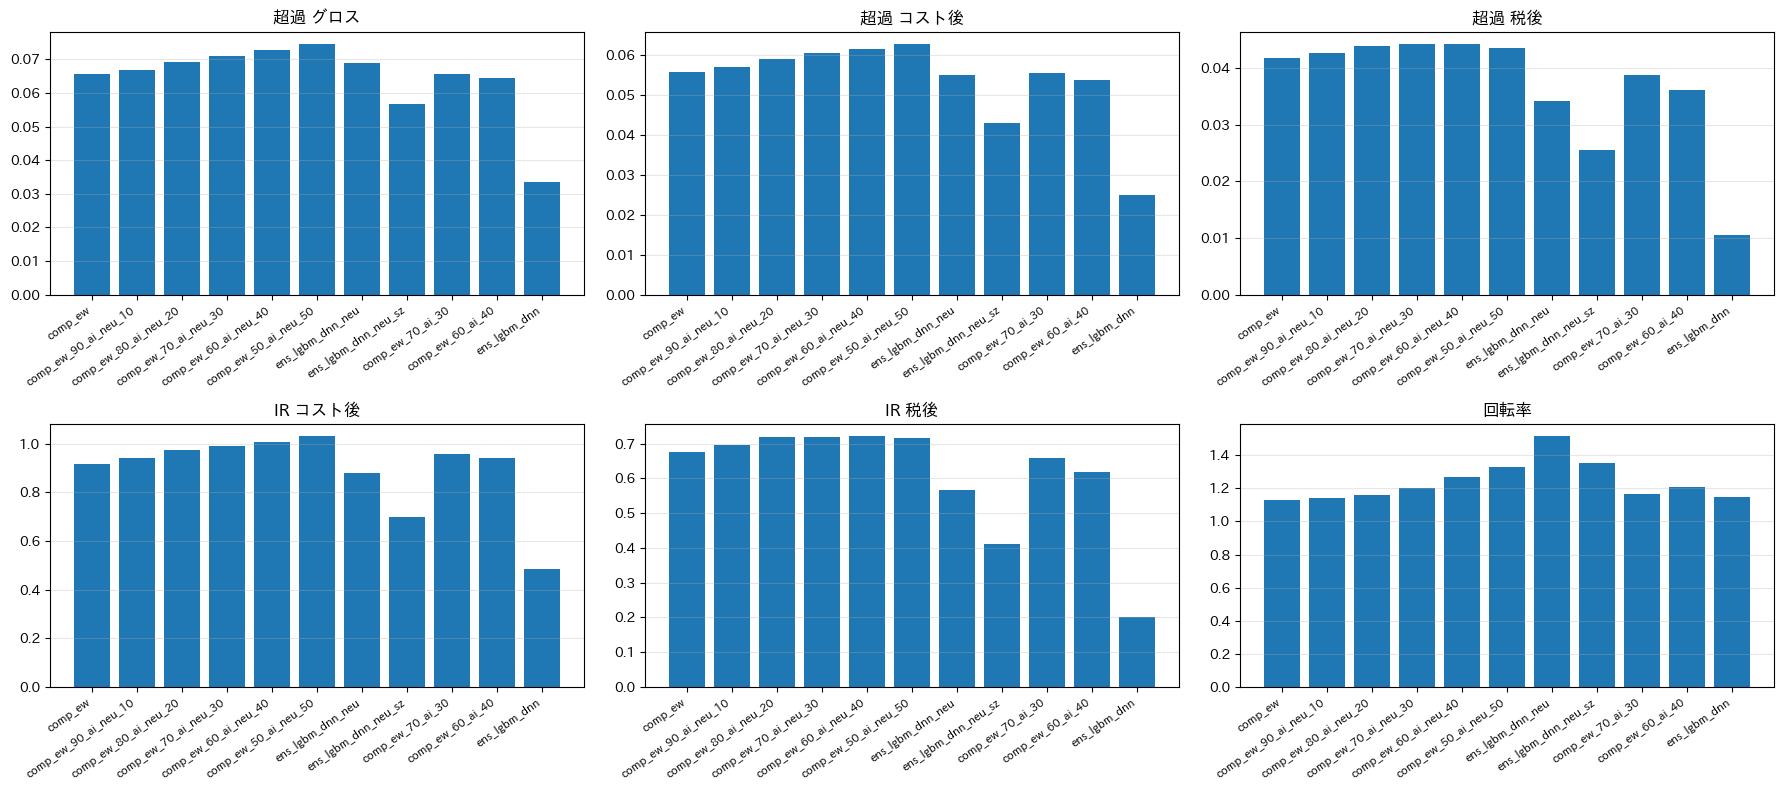

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for n, r in results.items():
    t = r.table.dropna(subset=["fund"]).iloc[BURN_IN:]
    tt = r.tax_table
    lw = 2.2 if n in HIGHLIGHT else 0.9
    axes[0].plot(t.index, (1 + t["excess_gross"]).cumprod(), label=n, linewidth=lw)
    axes[1].plot(t.index, (1 + t["excess"]).cumprod(), label=n, linewidth=lw)
    axes[2].plot(tt.index, (1 + tt["excess_after_tax"]).cumprod(), label=n, linewidth=lw)
for ax, title in zip(axes, ["超過（グロス）", "超過（コスト後）", "超過（税後）"]):
    ax.axhline(1, color="k", linewidth=0.8)
    ax.set_title(f"対 MSCI India 累積{title}")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.ravel(), ["超過 グロス", "超過 コスト後", "超過 税後", "IR コスト後", "IR 税後", "回転率"]):
    vals = tbl[col]
    ax.bar(np.arange(len(vals)), vals, color=["C0" if v >= 0 else "C3" for v in vals])
    ax.set_xticks(np.arange(len(vals)), vals.index, rotation=35, ha="right", fontsize=8)
    ax.set_title(col)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## 4. 混合比率と指標（中立化版との複合 vs 生スコアとの複合）

生スコア系統は `03_bax_results` の結果（同条件）を再計算して並べる。

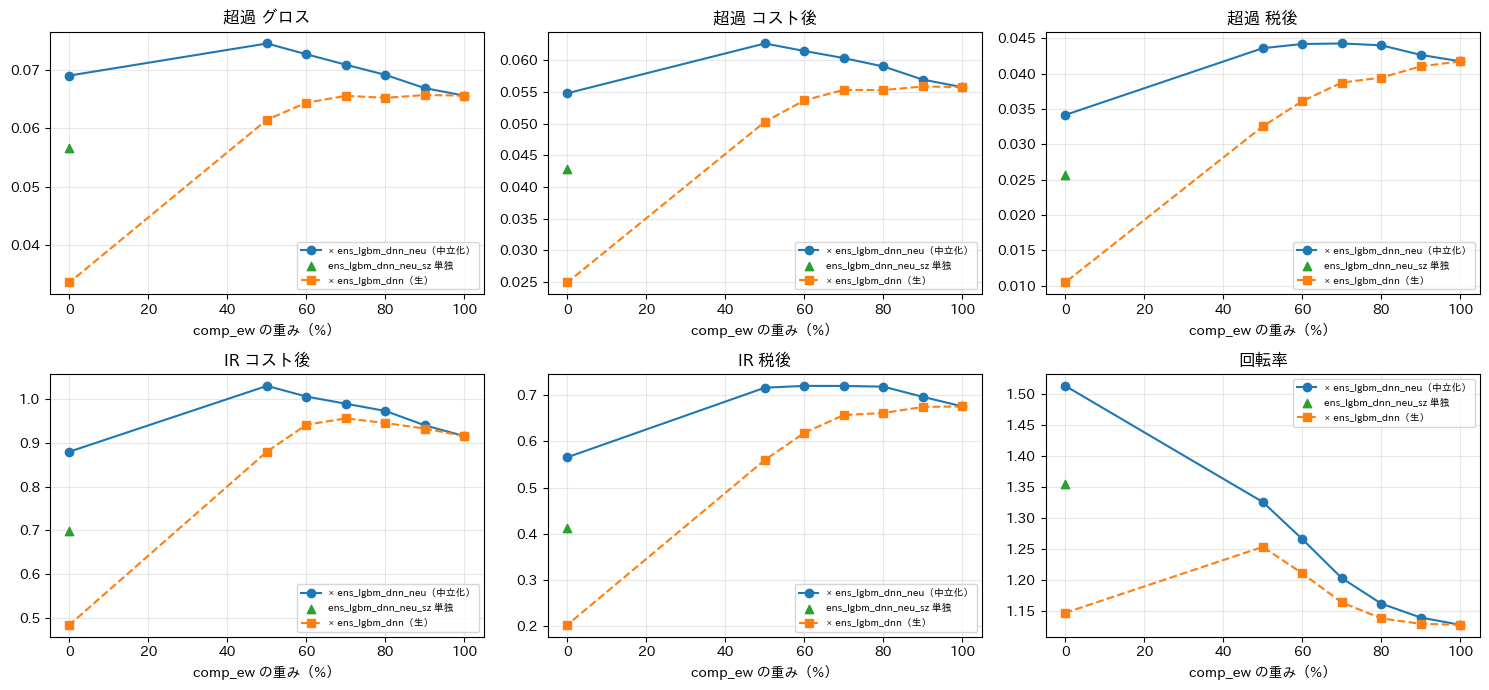

In [5]:
raw_family = ["comp_ew"] + [f"comp_ew_{w}_ai_{100 - w}" for w in W] + ["ens_lgbm_dnn"]
raw_tbl = {}
for n in raw_family:
    if n in results:
        raw_tbl[n] = tbl.loc[n]
    else:
        out = BaxOutput(f"{BAX_ROOT}/{n}")
        r = evaluate_bax(out, tax_schedule=schedule, tax_returns=rtn_inr, burn_in=BURN_IN)
        s = r.summary; tt = r.tax_table; net = performance_summary(tt["fund_after_tax"], tt["bm"])
        raw_tbl[n] = pd.Series({"超過 グロス": s["active_return_gross"], "超過 コスト後": s["active_return"], "超過 税後": net["active_return"], "IR コスト後": s["information_ratio"], "IR 税後": net["information_ratio"], "回転率": s["turnover_annual"]})
raw_tbl = pd.DataFrame(raw_tbl).T
neu_family = ["comp_ew"] + NEU + ["ens_lgbm_dnn_neu"]
xw = [100] + W + [0]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), ["超過 グロス", "超過 コスト後", "超過 税後", "IR コスト後", "IR 税後", "回転率"]):
    ax.plot(xw, [tbl.loc[n, col] for n in neu_family], marker="o", label="× ens_lgbm_dnn_neu（中立化）")
    ax.scatter([0], [tbl.loc["ens_lgbm_dnn_neu_sz", col]], marker="^", color="C2", zorder=5, label="ens_lgbm_dnn_neu_sz 単独")
    ax.plot(xw, [raw_tbl.loc[n, col] for n in raw_family], marker="s", linestyle="--", label="× ens_lgbm_dnn（生）")
    ax.set_xlabel("comp_ew の重み（%）")
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 5. 制約の張り付き

In [6]:
rows = {}
for n, out in outs.items():
    obj = out.objective().iloc[1:]
    perf = out.performance().iloc[1:]
    h = results[n].holdings
    ind = results[n].exposures["industry"]
    rows[n] = {
        "omega 平均": obj["omega"].mean(), "omega ≥ 4.9% の月": (obj["omega"] >= 0.049).mean(),
        "回転率 ≥ 14.9% の月": (perf["rot"] >= 0.149).mean(), "回転率 平均/月": perf["rot"].mean(),
        "業種 下限張り付き（平均本数）": ind["at_lower"].sum(), "業種 上限張り付き（平均本数）": ind["at_upper"].sum(),
        "個別 上限張り付き（平均）": h["n_at_upper"].mean(), "個別 下限張り付き（平均）": h["n_at_lower"].mean(),
        "アルファ（opt 加重）": h["alpha_weighted"].mean(), "アルファ（BM 加重）": h["alpha_bm_weighted"].mean(),
    }
display(pd.DataFrame(rows).T.round(3))

,omega 平均,omega ≥ 4.9% の月,回転率 ≥ 14.9% の月,回転率 平均/月,業種 下限張り付き（平均本数）,業種 上限張り付き（平均本数）,個別 上限張り付き（平均）,個別 下限張り付き（平均）,アルファ（opt 加重）,アルファ（BM 加重）
comp_ew,0.049,0.810,0.018,0.094,2.049,1.256,3.939,3.470,1.020,0.046
comp_ew_90_ai_neu_10,0.049,0.840,0.031,0.095,2.055,1.250,3.890,3.610,1.006,0.017
comp_ew_80_ai_neu_20,0.049,0.847,0.049,0.097,2.024,1.256,3.646,3.616,0.990,-0.009
comp_ew_70_ai_neu_30,0.049,0.853,0.061,0.100,2.000,1.262,3.598,3.774,0.974,-0.039
comp_ew_60_ai_neu_40,0.049,0.865,0.098,0.105,2.024,1.250,3.567,3.817,0.959,-0.063
comp_ew_50_ai_neu_50,0.049,0.871,0.160,0.110,1.927,1.323,3.518,3.921,0.944,-0.084
ens_lgbm_dnn_neu,0.049,0.767,0.497,0.126,1.354,1.244,3.555,4.305,0.895,-0.155
ens_lgbm_dnn_neu_sz,0.048,0.558,0.276,0.113,1.677,1.317,3.561,4.244,0.959,0.027
comp_ew_70_ai_30,0.049,0.767,0.025,0.097,1.878,1.091,4.256,3.549,1.105,0.283
comp_ew_60_ai_40,0.048,0.736,0.067,0.101,1.854,1.037,4.585,3.543,1.130,0.375


## 6. リスクモデルによる分解（Style / Industry / Country / Specific）

,寄与 Style,寄与 Industry,寄与 Country,寄与 specific,寄与 合計,リスク分散シェア Style,リスク分散シェア Industry,リスク分散シェア specific,te_factor,te_specific
comp_ew,0.0140,0.0033,0.0015,0.0495,0.0684,0.2696,0.0194,0.6671,0.0282,0.0401
comp_ew_70_ai_neu_30,0.0139,0.0029,0.0011,0.0547,0.0726,0.2701,0.0206,0.6531,0.0289,0.0397
comp_ew_50_ai_neu_50,0.0136,0.0018,0.0013,0.0587,0.0754,0.2613,0.0217,0.6473,0.0290,0.0395
ens_lgbm_dnn_neu,0.0071,0.0014,0.0020,0.0585,0.0690,0.2229,0.0218,0.6461,0.0290,0.0393
ens_lgbm_dnn_neu_sz,0.0040,0.0010,0.0004,0.0523,0.0577,0.2628,0.0226,0.6679,0.0274,0.0388
comp_ew_70_ai_30,0.0163,0.0035,0.0000,0.0468,0.0667,0.2832,0.0212,0.6654,0.0280,0.0396
ens_lgbm_dnn,0.0127,0.0041,-0.0014,0.0186,0.0340,0.2192,0.0371,0.6969,0.0224,0.0338


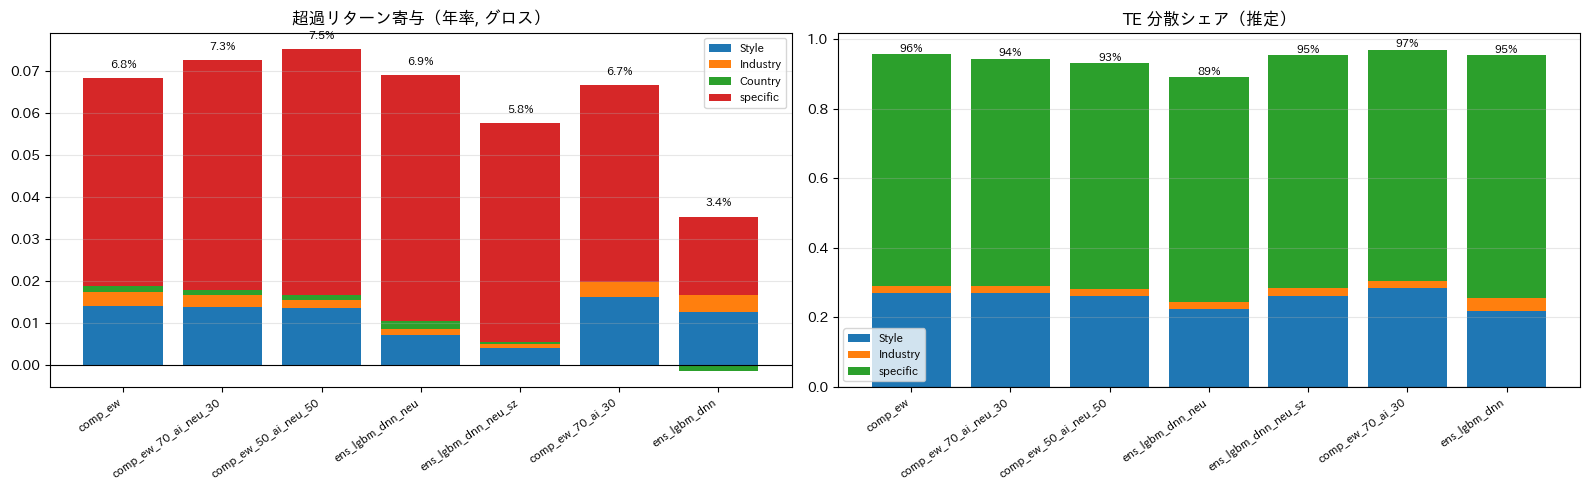

In [7]:
fl = store.factor_list(RISK_MODEL)
fr = store.factor_return(RISK_MODEL)
rows = {}
for n in ["comp_ew", "comp_ew_70_ai_neu_30", "comp_ew_50_ai_neu_50", "ens_lgbm_dnn_neu", "ens_lgbm_dnn_neu_sz", "comp_ew_70_ai_30", "ens_lgbm_dnn"]:
    groups, _ = factor_attribution(outs[n], fr, fl)
    rd = risk_decomposition(outs[n], lambda d: store.factor_covariance(RISK_MODEL, d), fl)
    g = groups.iloc[BURN_IN:]
    rows[n] = {**{f"寄与 {c}": g[c].mean() * 12 for c in ["Style", "Industry", "Country", "specific"]}, "寄与 合計": g["excess_gross"].mean() * 12,
               **{f"リスク分散シェア {c}": rd[f"share_{c}"].mean() for c in ["Style", "Industry", "specific"]}, "te_factor": rd["te_factor"].mean(), "te_specific": rd["te_specific"].mean()}
decomp = pd.DataFrame(rows).T
display(decomp.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
contrib_cols = ["寄与 Style", "寄与 Industry", "寄与 Country", "寄与 specific"]
share_cols = ["リスク分散シェア Style", "リスク分散シェア Industry", "リスク分散シェア specific"]
x = np.arange(len(decomp))
for ax, cols, title, fmt in [
    (axes[0], contrib_cols, "超過リターン寄与（年率, グロス）", lambda v: f"{v:.1%}"),
    (axes[1], share_cols, "TE 分散シェア（推定）", lambda v: f"{v:.0%}"),
]:
    pos = np.zeros(len(decomp))
    neg = np.zeros(len(decomp))
    for c in cols:
        v = decomp[c].to_numpy()
        base = np.where(v >= 0, pos, neg)
        ax.bar(x, v, bottom=base, label=c.split(" ")[-1])
        pos += np.where(v >= 0, v, 0)
        neg += np.where(v < 0, v, 0)
    tot = decomp[cols].sum(axis=1).to_numpy()
    for i, t in enumerate(tot):
        ax.text(i, pos[i] + 0.002, fmt(t), ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x, decomp.index, rotation=35, ha="right", fontsize=8)
    ax.set_title(title)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. 制約なしの Q5 等ウェイトとの比較（実現率）

In [8]:
start, end = first.rebalance_dates.min(), first.rebalance_dates.max()
univ = store.universe(start, end)
bm_w = store.benchmark(BENCHMARK, start, end)
rtn_usd = store.returns(RISK_MODEL, "rtn_usd", start, None)
bm_ret = portfolio_returns(bm_w, rtn_usd)
rows = {}
for n in NAMES:
    q = quantile_analysis(store.alpha(SCORE_PATH[n], start, end), rtn_usd, univ, n_quantiles=5)
    r = q.returns[q.top].iloc[BURN_IN:]
    s = performance_summary(r, bm_ret.reindex(r.index), q.turnover[q.top].reindex(r.index))
    rows[n] = {"Q5 EW 超過（制約なし）": s["active_return"], "Q5 EW IR": s["information_ratio"], "Q5 EW 回転率": s["turnover_annual"], "最適化 グロス超過": tbl.loc[n, "超過 グロス"], "最適化 IR": tbl.loc[n, "IR コスト後"], "実現率": tbl.loc[n, "超過 グロス"] / s["active_return"]}
display(pd.DataFrame(rows).T.round(3))

,Q5 EW 超過（制約なし）,Q5 EW IR,Q5 EW 回転率,最適化 グロス超過,最適化 IR,実現率
comp_ew,0.131,1.159,4.046,0.066,0.915,0.499
comp_ew_90_ai_neu_10,0.131,1.162,4.100,0.067,0.940,0.512
comp_ew_80_ai_neu_20,0.137,1.221,4.190,0.069,0.973,0.504
comp_ew_70_ai_neu_30,0.144,1.267,4.333,0.071,0.989,0.492
comp_ew_60_ai_neu_40,0.143,1.269,4.466,0.073,1.006,0.507
comp_ew_50_ai_neu_50,0.143,1.299,4.655,0.075,1.030,0.520
ens_lgbm_dnn_neu,0.127,1.190,5.475,0.069,0.880,0.544
ens_lgbm_dnn_neu_sz,0.126,1.297,5.252,0.057,0.698,0.448
comp_ew_70_ai_30,0.134,1.320,4.218,0.066,0.956,0.491
comp_ew_60_ai_40,0.134,1.382,4.388,0.064,0.941,0.480


## 所見


**1. 中立化は制約付き最適化でも効いた。** 生スコア `ens_lgbm_dnn` 単独は IR 0.48（コスト後）だったが、
`ens_lgbm_dnn_neu`（サイズ + vola60 + セクター中立化）単独は IR 0.88、グロス超過 6.9% と comp_ew 単独（IR 0.92、6.6%）にほぼ並ぶ。
`03_bax_results` で生スコアが負けていた原因（サイズ・低ボラへの傾斜が制約に吸収される）は、中立化で解消されたと言える。
サイズ + セクターのみの `neu_sz` は IR 0.70 にとどまり、vola60 の中立化が効いている。

**2. ただし単独採用は勧めない。** `ens_lgbm_dnn_neu` は回転率 151%/年（comp_ew 113%）、月次回転率 15% 上限に半分の月で張り付き、
短期譲渡益比率 60%。税後では超過 3.4% / IR 0.57 と comp_ew（4.2% / 0.68）を下回る。
`neu` 単独の勝率 59%、最大 DD −14.8% も comp_ew より悪い。

**3. 複合は中立化版の方が全比率で生スコア版を上回る。** 混合比率図（§4）で中立化系統は生系統を全指標で上回り、
生系統が 70:30 で頭打ちになるのに対し、中立化系統は comp_ew の重みを下げるほど単調に改善する（グロス超過 6.6% → 7.5%、IR 0.92 → 1.03 @50:50）。
生スコア複合では AI 比率を上げると BM 加重アルファが正に大きくなり（= BM 寄りの銘柄が高スコアで、アクティブに取れない）、
中立化複合ではそれがほぼゼロ〜負で、アクティブ運用に素直に乗る。

**4. 税後で見ると 60:40〜70:30 が実質的な最適点。** 税後超過は 80:20〜50:50 でほぼ横並び（4.4%）、税後 IR は 70:30 / 60:40 が最大（0.72）。
50:50 はグロスでは最良だが回転率 133% と税ドラッグ 1.9% で税後の優位が消える。回転率を comp_ew 比 +10%pt 以内に抑えるなら 70:30、
+15%pt まで許容するなら 60:40 が候補。

**5. 超過リターンの源泉は依然 specific が 7 割強。** 中立化複合 70:30 の Style 寄与は comp_ew と同じ 1.4%/年で、
増分（+0.4%/年）はすべて specific 寄与。中立化で AI の寄与がファクター経由でなく銘柄選択経由に純化しており、
リスク分解でも Style シェア 27% と comp_ew と変わらない。

**6. 実現率は約 50% で変わらず。** 制約なし Q5 EW（USD）の超過 14% に対して最適化は 7%。中立化単独（`neu`）は実現率 54% と最も高く、
制約との相性は改善している。残り半分は TE 5% 制約と個別 ±3% 制約が吸収しており、これは comp_ew と同じ構造。

**次のステップ案**
- 70:30 / 60:40 で回転率制約 cs_rot を 0.10〜0.12 に下げたときの税後比較（回転率を comp_ew 並みに戻せるか）。
- AI 側のスコア更新頻度を落とす（hl1 のような平滑化を中立化後に適用）ことで回転率を削る案。
- 期間別（2014–2019 / 2020–2026）で中立化複合の優位が安定しているかの確認。